In [241]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
import os

In [242]:
data_dir = './Task-1'
scene_image_path = os.path.join(data_dir, "img4.png")
sign_image_path = os.path.join(data_dir, "rh_sign.jpg")

scene_image = cv2.imread(scene_image_path)
sign_image = cv2.imread(sign_image_path)


def bgr_to_rgb(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


In [243]:
def plot_images(images, titles=None, cols=3, figsize=(15, 10)):
    # Number of images
    num_images = len(images)
    
    # Calculate number of rows
    rows = math.ceil(num_images / cols)
    
    # Create the subplot grid
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.ravel()  # Flatten the 2D grid of axes to iterate over
    
    # Loop through each image and corresponding axis
    for i in range(rows * cols):
        if i < num_images:
            # Display image
            axes[i].imshow(images[i], cmap='gray' if len(images[i].shape) == 2 else None)
            
            # Add title if provided
            if titles:
                axes[i].set_title(titles[i], fontsize=12)
        else:
            # Hide any unused subplot
            axes[i].axis('off')
        
        # Remove axes for clarity
        axes[i].axis('off')
    
    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()

In [244]:
def get_reference_contour(sign_image):
    """Extract contour from reference sign image"""
    
    gray = cv2.cvtColor(sign_image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        raise ValueError("No contours found in template")

    
    cv2.drawContours(thresh, contours, -1, (0,255,0), 2)
    reference_contour = max(contours, key=cv2.contourArea)

    return reference_contour, thresh


def is_triangle(contour, tolerance=0.04):
    """Check if a contour is a triangle using polygon approximation."""
    perimeter = cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, tolerance * perimeter, True)
    return len(approx) == 3, approx  # Return whether it's a triangle and the approximation


def red_color_thresholding(image):
    """Apply red color thresholding to detect red regions in the image."""
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    # Define the range for detecting red color
    lower_red1 = np.array([0, 50, 50])      # Lower bound for the first red range
    upper_red1 = np.array([5, 255, 255])   # Upper bound for the first red range
    lower_red2 = np.array([165, 50, 50])   # Lower bound for the second red range
    upper_red2 = np.array([180, 255, 255]) # Upper bound for the second red range
    
    # Create masks for the red regions
    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
    
    # Combine the two masks
    mask = cv2.bitwise_or(mask1, mask2)
    
    return mask


def locate_rh_sign(sign_image, scene_image):
    """Detect the most similar triangle contour to the reference sign."""

    debug = True
    similarity_threshold = 0.2
        
    debug_images = []
    debug_titles = []
    debug_images.append(scene_image.copy())
    debug_titles.append('Original')

    reference_contour, thresh = get_reference_contour(sign_image)
    debug_images.append(thresh)
    debug_titles.append('Ref Contour')
    
    # Convert image to grayscale
    scene_image_gray = cv2.cvtColor(scene_image, cv2.COLOR_BGR2GRAY)
    debug_images.append(scene_image_gray)
    debug_titles.append('Grayscale')
    
    # Binary thresholding
    _, binary_thresh = cv2.threshold(scene_image_gray, 127, 255, cv2.THRESH_BINARY)
    debug_images.append(binary_thresh)
    debug_titles.append('Binary Threshold')
    
    # Adaptive thresholding
    adaptive_thresh = cv2.adaptiveThreshold(scene_image_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                  cv2.THRESH_BINARY, 11, 2)
    debug_images.append(adaptive_thresh)
    debug_titles.append('Adaptive Threshold')
    
    # Edge detection
    edges = cv2.Canny(scene_image_gray, 30, 150)
    debug_images.append(edges)
    debug_titles.append('Edges')
    
    # Red color thresholding
    red_mask = red_color_thresholding(scene_image)
    debug_images.append(red_mask)
    debug_titles.append('Red Color Thresholding')
    
    preprocessed_images = [binary_thresh, adaptive_thresh, edges, red_mask]
    best_detection = None  # Track the best detection
    
    for idx, processed in enumerate(preprocessed_images):
        contours, _ = cv2.findContours(processed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        contour_image = scene_image.copy()
        cv2.drawContours(contour_image, contours, -1, (0,255,0), 2)
        debug_images.append(contour_image)
        debug_titles.append(f'Contours Method {idx+1}')
        
        for contour in contours:
            if cv2.contourArea(contour) < 100:
                continue
                
            is_tri, approx = is_triangle(contour)
            if not is_tri:
                continue

            similarity = cv2.matchShapes(reference_contour, approx, cv2.CONTOURS_MATCH_I2, 0.0)
            if similarity < similarity_threshold:
                x, y, w, h = cv2.boundingRect(approx)
                detection = (x, y, w, h, similarity, approx)
                
                # Update the best detection based on similarity
                if best_detection is None or similarity < best_detection[4]:
                    best_detection = detection

    final_image = scene_image.copy()
    
    if best_detection:
        x, y, w, h, similarity, approx = best_detection
        cv2.drawContours(final_image, [approx], -1, (0,255,0), 2)
        cv2.rectangle(final_image, (x, y), (x+w, y+h), (255,0,0), 2)
        cv2.putText(final_image, f'Similarity: {similarity:.3f}', (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 2)
    else:
        print("No triangles detected with sufficient similarity.")
    
    debug_images.append(final_image)
    debug_titles.append('Best Detection')
    
    if debug:
        rows = (len(debug_images) + 3) // 4
        fig, axes = plt.subplots(rows, 4, figsize=(20, 5*rows))
        axes = axes.ravel()
        
        for idx, (img, title) in enumerate(zip(debug_images, debug_titles)):
            if len(img.shape) == 2:
                axes[idx].imshow(img, cmap='gray')
            else:
                axes[idx].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            axes[idx].set_title(title)
            axes[idx].axis('off')
        
        for idx in range(len(debug_images), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.savefig('contour_matching_debug.jpg')
        plt.close()
    
    return (x, y, w, h) if best_detection else None

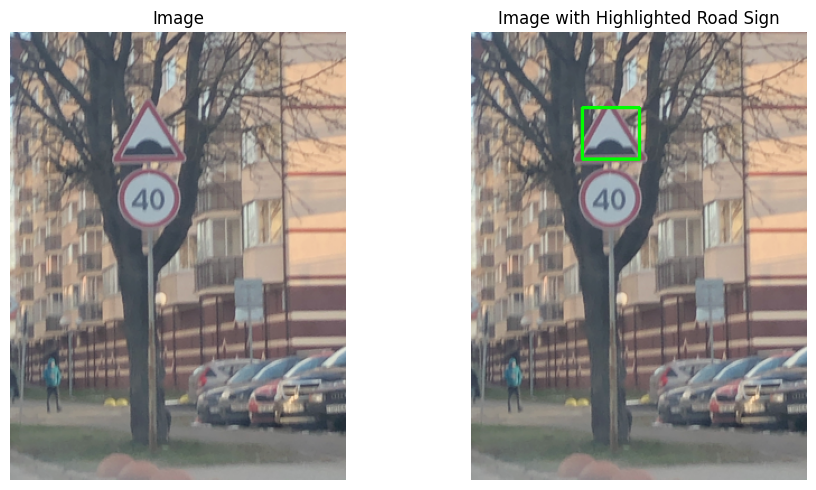

In [245]:
detection = locate_rh_sign(sign_image, scene_image)

if detection:
    x, y, w, h = detection

    final_image = scene_image.copy()
    cv2.rectangle(final_image, (x, y), (x + w, y + h), (0, 255, 0), 2)

    plot_images(
        images=[bgr_to_rgb(scene_image), bgr_to_rgb(final_image)],
        titles=["Image", "Image with Highlighted Road Sign"],
        cols=2,
        figsize=(10, 5)
    )
else:
    print("No triangles detected")